In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import os
import copy
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/CompNeurProject'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')
GRAPH_DIR = os.path.join(PROJECT_DIR, 'graphs')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(GRAPH_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# load data from data dir
transform = transforms.Compose([transforms.ToTensor()])
training_set = torchvision.datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=transform)
testing_set = torchvision.datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=transform)

# batching and shuffling data
train_loader = torch.utils.data.DataLoader(training_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(testing_set, batch_size=5000, shuffle=False)

In [ ]:
class NoiseInjector(nn.Module):
  def __init__(self, noise_type='awgn', intensity=0.0):
    super(NoiseInjector, self).__init__()
    self.noise_type = noise_type.lower()
    self.intensity = intensity

  def forward(self, x):
    if self.intensity == 0.0:
        return x

    # Additive White Gaussian Noise
    if self.noise_type == 'awgn':
      noise = torch.randn_like(x) * self.intensity
      return torch.clamp(x + noise, 0., 1.)

    # Occlusion - drops pixels
    elif self.noise_type == 'masking':
      mask = torch.rand_like(x) > self.intensity
      return x * mask

    # Contrast reduction + AWGN combined
    elif self.noise_type == 'contrast':
      reduced = 0.5 + (x - 0.5) * (1 - self.intensity)
      noise = torch.randn_like(x) * self.intensity * 0.5
      return torch.clamp(reduced + noise, 0., 1.)

    # Motion blur - horizontal streaking effect
    elif self.noise_type == 'motion_blur':
      kernel_size = max(1, int(self.intensity * 15))
      if kernel_size % 2 == 0:
          kernel_size += 1  # must be odd for symmetric padding
      kernel = torch.zeros(1, 1, 1, kernel_size, device=x.device)
      kernel[0, 0, 0, :] = 1.0 / kernel_size
      # apply same kernel to each image in batch
      batch_size, channels, h, w = x.shape
      x_reshaped = x.view(batch_size * channels, 1, h, w)
      blurred = torch.nn.functional.conv2d(
          x_reshaped, kernel, padding=(0, kernel_size // 2)
      )
      return blurred.view(batch_size, channels, h, w)

    return x

In [ ]:
class StandardCNN(nn.Module):
  def __init__(self, noise_type='awgn', noise_intensity=0.0):
    super(StandardCNN, self).__init__()

    self.noise = NoiseInjector(noise_type=noise_type, intensity=noise_intensity)

    # convolution layers
    # extracts 16 features from MNIST image (grayscale) using 3x3 filter
    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, dilation=1)
    # expands from 16 features to 32 using dilated filter
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=2, dilation=2)
    # slides 2x2 window over feature maps and gets max values
    self.pool = nn.MaxPool2d(2, 2)

    self.latent_dim = 128
    # fully connected layer, compresses from 1568 dim (32 feature maps * 7 height * 7 width) to 128
    self.fc_latent = nn.Linear(1568, self.latent_dim)
    # output fully connected layer, maps 128 features to 10 digits (0-9)
    self.classifier = nn.Linear(self.latent_dim, 10)

  def forward(self, x):
    # add noise to image
    x = self.noise(x)
    # conv layer finds features and uses relu activation function to turn negative numbers to 0
    # pool shrinks 28x28 to 14x14
    x = self.pool(torch.nn.functional.relu(self.conv1(x)))
    # second conv layer finds more complex features and pool shrinks to 7x7
    x = self.pool(torch.nn.functional.relu(self.conv2(x)))
    # flatten 32x7x7 into 1D array of 1568
    x = x.view(-1, 1568)

    # pass through first fully connected layer to 128-dim feature representation
    latent_features = torch.nn.functional.relu(self.fc_latent(x))

    # final classification mapping 128 to 10 class probabilities
    output = self.classifier(latent_features)
    return output

In [ ]:
class HopfieldNetwork(nn.Module):
  def __init__(self, latent_dim):
      super(HopfieldNetwork, self).__init__()
      # 128 from cnn output
      self.latent_dim = latent_dim
      # save matrix but don't calculate gradients during backprop because it will come from hebbian learning
      self.register_buffer('weight_matrix', torch.zeros(latent_dim, latent_dim))

  # stores "clean" digit patterns
  def store_patterns(self, patterns):
      X = patterns.float() # [10 classes, 128 features]

      # calculate correlation between all 10 digit patterns (10x10 matrix)
      correlation_matrix = torch.matmul(X, X.T)

      # pseudo-inverse of the correlation matrix
      inverse_correlation = torch.linalg.pinv(correlation_matrix)

      # calculate final 128x128 weight matrix
      W = torch.matmul(torch.matmul(X.T, inverse_correlation), X)

      # neurons do not synapse onto themselves
      W.fill_diagonal_(0)
      self.weight_matrix = W

  # retrieves pattern given noisy feature vector from cnn using attractor states
  def forward(self, x, iterations=5):
      state = x.clone()
      # updates iteratively to move around network and settle in a stored memory
      for _ in range(iterations):
        # calculates the sum of the excitatory and inhibitory signals it is receiving from all other neurons.
        activation = torch.matmul(state, self.weight_matrix)
        # gets the sign (threshold) - positive = 1, negative = -1
        state = torch.sign(activation)
        state[state == 0] = 1
      # return the final cleaned vector
      agreement = (state * x).sum(dim=1, keepdim=True)
      state = torch.where(agreement < 0, -state, state)
      return state

In [ ]:
class HybridCNN(nn.Module):
  def __init__(self, pretrained_cnn, hopfield_net):
    super(HybridCNN, self).__init__()

    # borrow the pretrained CNN's layers
    self.noise = pretrained_cnn.noise
    self.conv1 = copy.deepcopy(pretrained_cnn.conv1)
    self.conv2 = copy.deepcopy(pretrained_cnn.conv2)
    self.pool = pretrained_cnn.pool
    self.fc_latent = copy.deepcopy(pretrained_cnn.fc_latent)
    self.hopfield = hopfield_net

    # 128 continuous + 128 hopfield = 256 inputs
    self.hybrid_classifier = nn.Linear(256, 10)

  def forward(self, x):
    # same CNN feature extraction as StandardCNN
    x = self.noise(x)
    x = self.pool(torch.nn.functional.relu(self.conv1(x)))
    x = self.pool(torch.nn.functional.relu(self.conv2(x)))
    x = x.view(-1, 1568)
    latent_features = torch.nn.functional.relu(self.fc_latent(x))

    # mean-centered binarization for Hopfield
    mean = latent_features.mean(dim=1, keepdim=True)
    binary_features = torch.sign(latent_features - mean)
    binary_features[binary_features == 0] = 1

    # hopfield cleanup
    cleaned_features = self.hopfield(binary_features)

    # merge cnn and hopfield results
    combined_features = torch.cat([latent_features, cleaned_features.float()], dim=1)

    # final classification
    output = self.hybrid_classifier(combined_features)
    return output

In [ ]:
def train_hopfield_memory(pretrained_cnn, hopfield_net, train_loader, device):
  pretrained_cnn.eval()

  # keep running total of features for each digit
  class_feature_sums = {i: torch.zeros(128).to(device) for i in range(10)}
  class_counts = {i: 0 for i in range(10)}

  with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # pass images through the CNN feature layers
        x = pretrained_cnn.pool(torch.nn.functional.relu(pretrained_cnn.conv1(images)))
        x = pretrained_cnn.pool(torch.nn.functional.relu(pretrained_cnn.conv2(x)))
        x = x.view(-1, 1568)
        latent_features = torch.nn.functional.relu(pretrained_cnn.fc_latent(x))

        # add features to digit classes
        for idx, label in enumerate(labels):
            digit = label.item()
            class_feature_sums[digit] += latent_features[idx]
            class_counts[digit] += 1

  prototypes = []
  for i in range(10):
    # average vector for this digit
    avg_vector = class_feature_sums[i] / class_counts[i]

    # convert continuous values to -1 and 1 for the Hopfield network
    mean = avg_vector.mean()
    activation_state = torch.sign(avg_vector - mean)
    activation_state[activation_state == 0] = 1
    prototypes.append(activation_state)
  prototype_tensor = torch.stack(prototypes)

  # store tensors in Hopfield Network using hebbian learning
  hopfield_net.store_patterns(prototype_tensor)

In [ ]:
CNN_PATH = os.path.join(MODEL_DIR, 'standard_cnn_weights.pth')
HNN_PATH = os.path.join(MODEL_DIR, 'hopfield_memory_weights.pth')

pretrained_cnn = StandardCNN(noise_intensity=0.0).to(device)
loaded_hnn = HopfieldNetwork(latent_dim=128).to(device)

if os.path.exists(CNN_PATH) and os.path.exists(HNN_PATH):
    print("Loading weights")
    pretrained_cnn.load_state_dict(torch.load(CNN_PATH, map_location=device))
    loaded_hnn.load_state_dict(torch.load(HNN_PATH, map_location=device))
else:
  print("Starting training phase")
  # train at 20% noise
  pretrained_cnn.noise.intensity = 0.2
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(pretrained_cnn.parameters(), lr=0.001)

  pretrained_cnn.train()
  epochs = 5
  for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(train_loader, 0):
          inputs, labels = data[0].to(device), data[1].to(device)
          optimizer.zero_grad()
          outputs = pretrained_cnn(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          running_loss += loss.item()
          if i % 300 == 299:
              print(f"Epoch [{epoch + 1}/{epochs}], Batch [{i + 1}/{len(train_loader)}], Loss: {running_loss / 300:.4f}")
              running_loss = 0.0

  torch.save(pretrained_cnn.state_dict(), CNN_PATH)
  print(f"CNN saved to {CNN_PATH}")

  # train Hopfield Memory on clean data
  pretrained_cnn.noise.intensity = 0.0
  train_hopfield_memory(pretrained_cnn, loaded_hnn, train_loader, device)
  torch.save(loaded_hnn.state_dict(), HNN_PATH)
  print(f"Hopfield memory saved to {HNN_PATH}")

Loading weights


###Comparison of Model Performance with Varying Noise Levels


Noise Type: AWGN
  Run 1 complete
  Run 2 complete
  Run 3 complete
  Run 4 complete
  Run 5 complete
Noise: 0.0 | CNN: 98.74% ± 0.00 | Hybrid: 98.99% ± 0.00
Noise: 0.1 | CNN: 98.52% ± 0.03 | Hybrid: 98.86% ± 0.02
Noise: 0.2 | CNN: 97.55% ± 0.03 | Hybrid: 98.55% ± 0.04
Noise: 0.3 | CNN: 92.33% ± 0.04 | Hybrid: 97.45% ± 0.07
Noise: 0.4 | CNN: 74.11% ± 0.11 | Hybrid: 91.51% ± 0.07
Noise: 0.5 | CNN: 51.64% ± 0.10 | Hybrid: 74.20% ± 0.23
Noise: 0.6 | CNN: 35.05% ± 0.11 | Hybrid: 52.90% ± 0.12
Noise: 0.7 | CNN: 25.22% ± 0.13 | Hybrid: 36.87% ± 0.16
Noise: 0.8 | CNN: 20.59% ± 0.12 | Hybrid: 27.04% ± 0.10
Noise: 0.9 | CNN: 17.45% ± 0.17 | Hybrid: 21.55% ± 0.13
Noise: 1.0 | CNN: 15.78% ± 0.05 | Hybrid: 18.29% ± 0.10


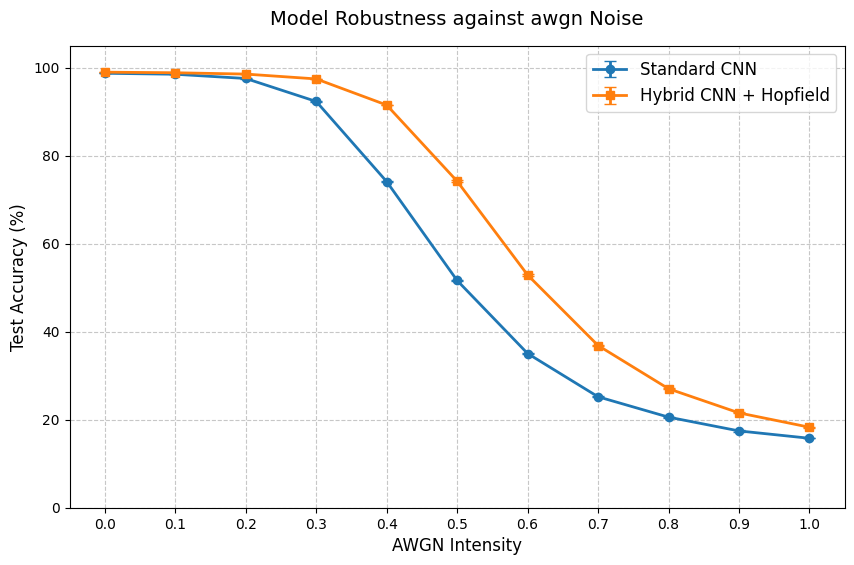

Saved graph to: /content/drive/MyDrive/CompNeurProject/graphs/results_awgn.png

Noise Type: MASKING
  Run 1 complete
  Run 2 complete
  Run 3 complete
  Run 4 complete
  Run 5 complete
Noise: 0.0 | CNN: 98.74% ± 0.00 | Hybrid: 98.99% ± 0.00
Noise: 0.1 | CNN: 98.22% ± 0.03 | Hybrid: 98.71% ± 0.01
Noise: 0.2 | CNN: 97.13% ± 0.02 | Hybrid: 98.22% ± 0.03
Noise: 0.3 | CNN: 95.03% ± 0.05 | Hybrid: 97.43% ± 0.05
Noise: 0.4 | CNN: 91.49% ± 0.10 | Hybrid: 96.09% ± 0.07
Noise: 0.5 | CNN: 85.05% ± 0.08 | Hybrid: 93.44% ± 0.08
Noise: 0.6 | CNN: 73.79% ± 0.09 | Hybrid: 88.15% ± 0.13
Noise: 0.7 | CNN: 59.33% ± 0.17 | Hybrid: 76.38% ± 0.16
Noise: 0.8 | CNN: 40.83% ± 0.12 | Hybrid: 55.20% ± 0.07
Noise: 0.9 | CNN: 22.88% ± 0.18 | Hybrid: 28.52% ± 0.09
Noise: 1.0 | CNN: 10.10% ± 0.00 | Hybrid: 11.35% ± 0.00


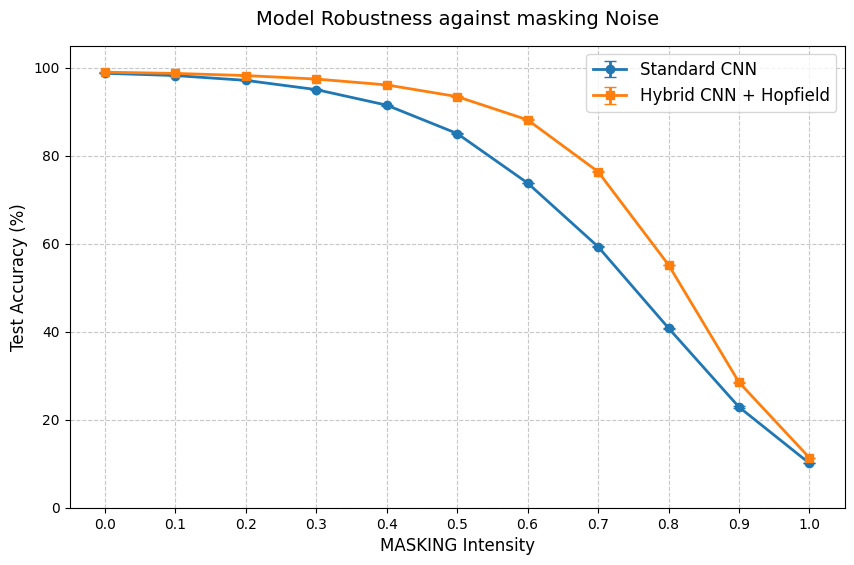

Saved graph to: /content/drive/MyDrive/CompNeurProject/graphs/results_masking.png

Noise Type: CONTRAST
  Run 1 complete
  Run 2 complete
  Run 3 complete
  Run 4 complete
  Run 5 complete
Noise: 0.0 | CNN: 98.74% ± 0.00 | Hybrid: 98.99% ± 0.00
Noise: 0.1 | CNN: 98.63% ± 0.01 | Hybrid: 98.90% ± 0.02
Noise: 0.2 | CNN: 98.05% ± 0.03 | Hybrid: 98.62% ± 0.03
Noise: 0.3 | CNN: 94.28% ± 0.06 | Hybrid: 97.64% ± 0.03
Noise: 0.4 | CNN: 70.36% ± 0.06 | Hybrid: 92.13% ± 0.10
Noise: 0.5 | CNN: 34.82% ± 0.10 | Hybrid: 60.79% ± 0.15
Noise: 0.6 | CNN: 18.01% ± 0.10 | Hybrid: 24.81% ± 0.18
Noise: 0.7 | CNN: 12.46% ± 0.10 | Hybrid: 13.54% ± 0.10
Noise: 0.8 | CNN: 10.40% ± 0.08 | Hybrid: 10.69% ± 0.10
Noise: 0.9 | CNN: 9.97% ± 0.10 | Hybrid: 9.71% ± 0.08
Noise: 1.0 | CNN: 10.14% ± 0.06 | Hybrid: 9.56% ± 0.09


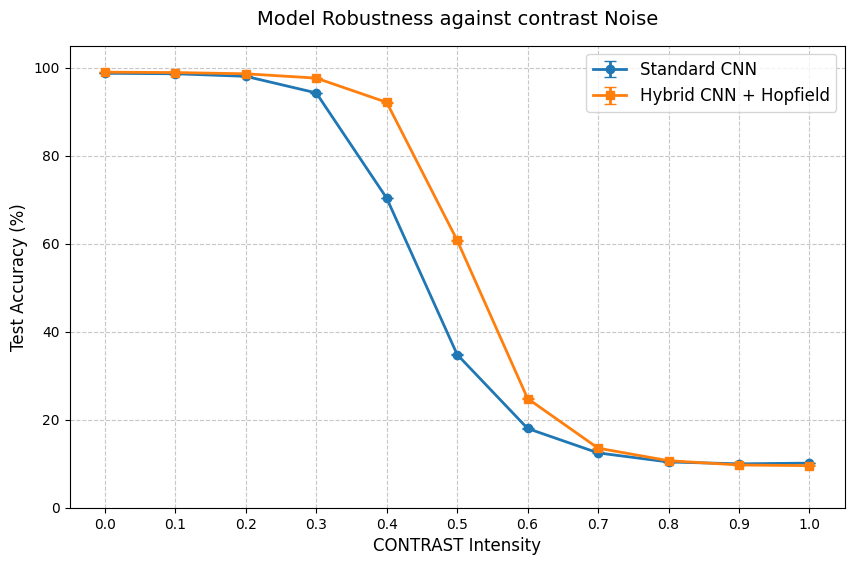

Saved graph to: /content/drive/MyDrive/CompNeurProject/graphs/results_contrast.png

Noise Type: MOTION_BLUR
  Run 1 complete
  Run 2 complete
  Run 3 complete
  Run 4 complete
  Run 5 complete
Noise: 0.0 | CNN: 98.74% ± 0.00 | Hybrid: 98.99% ± 0.00
Noise: 0.1 | CNN: 98.74% ± 0.00 | Hybrid: 98.99% ± 0.00
Noise: 0.2 | CNN: 98.48% ± 0.00 | Hybrid: 98.92% ± 0.00
Noise: 0.3 | CNN: 96.69% ± 0.00 | Hybrid: 97.90% ± 0.00
Noise: 0.4 | CNN: 83.96% ± 0.00 | Hybrid: 94.87% ± 0.00
Noise: 0.5 | CNN: 83.96% ± 0.00 | Hybrid: 94.87% ± 0.00
Noise: 0.6 | CNN: 76.85% ± 0.00 | Hybrid: 90.61% ± 0.00
Noise: 0.7 | CNN: 72.48% ± 0.00 | Hybrid: 85.31% ± 0.00
Noise: 0.8 | CNN: 68.85% ± 0.00 | Hybrid: 80.63% ± 0.00
Noise: 0.9 | CNN: 68.85% ± 0.00 | Hybrid: 80.63% ± 0.00
Noise: 1.0 | CNN: 66.42% ± 0.00 | Hybrid: 76.68% ± 0.00


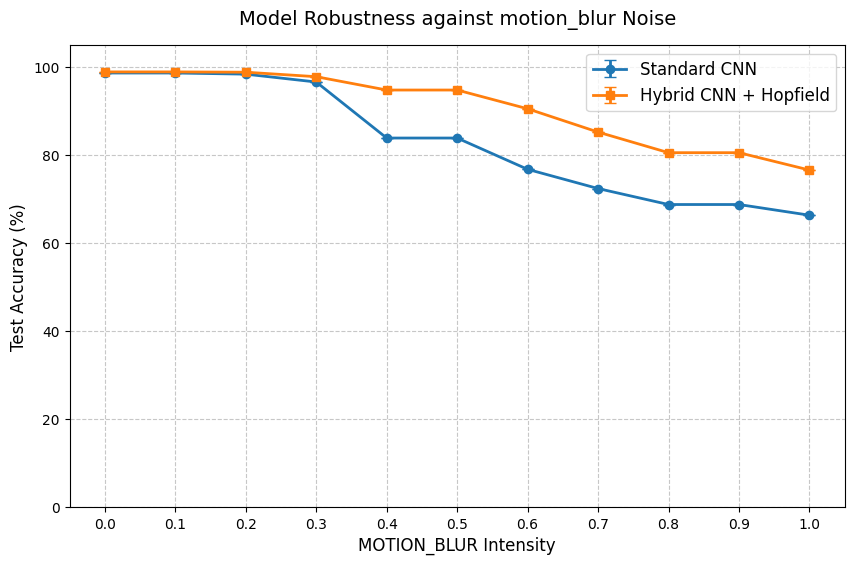

Saved graph to: /content/drive/MyDrive/CompNeurProject/graphs/results_motion_blur.png


In [ ]:
import numpy as np

def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

pretrained_cnn.eval()
loaded_hnn.eval()

hybrid_model = HybridCNN(pretrained_cnn, loaded_hnn).to(device)

hybrid_model.train()
hybrid_optimizer = optim.Adam(hybrid_model.hybrid_classifier.parameters(), lr=0.001)
hybrid_criterion = nn.CrossEntropyLoss()

# tune our model on noise
hybrid_model.noise.noise_type = 'awgn'
hybrid_model.noise.intensity = 0.3

for epoch in range(3):
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        hybrid_optimizer.zero_grad()
        outputs = hybrid_model(inputs)
        loss = hybrid_criterion(outputs, labels)
        loss.backward()
        hybrid_optimizer.step()

num_runs = 5
noise_types = ['awgn', 'masking', 'contrast', 'motion_blur']
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

with torch.no_grad():
    for n_type in noise_types:
        print(f"\nNoise Type: {n_type.upper()}")

        cnn_results = []
        hybrid_results = []

        for run in range(num_runs):
            cnn_run = []
            hybrid_run = []

            for noise in noise_levels:
                pretrained_cnn.noise.noise_type = n_type
                pretrained_cnn.noise.intensity = noise
                hybrid_model.noise.noise_type = n_type
                hybrid_model.noise.intensity = noise

                cnn_acc = evaluate_model(pretrained_cnn, test_loader, device)
                hybrid_acc = evaluate_model(hybrid_model, test_loader, device)

                cnn_run.append(cnn_acc)
                hybrid_run.append(hybrid_acc)

            cnn_results.append(cnn_run)
            hybrid_results.append(hybrid_run)
            print(f"  Run {run+1} complete")

        cnn_results = np.array(cnn_results)
        hybrid_results = np.array(hybrid_results)

        cnn_mean = cnn_results.mean(axis=0)
        cnn_se = cnn_results.std(axis=0) / np.sqrt(num_runs)
        hybrid_mean = hybrid_results.mean(axis=0)
        hybrid_se = hybrid_results.std(axis=0) / np.sqrt(num_runs)

        for i, noise in enumerate(noise_levels):
            print(f"Noise: {noise:.1f} | CNN: {cnn_mean[i]:.2f}% ± {cnn_se[i]:.2f} | Hybrid: {hybrid_mean[i]:.2f}% ± {hybrid_se[i]:.2f}")

        plt.figure(figsize=(10, 6))
        plt.errorbar(noise_levels, cnn_mean, yerr=cnn_se, marker='o',
                     linewidth=2, capsize=4, label='Standard CNN')
        plt.errorbar(noise_levels, hybrid_mean, yerr=hybrid_se, marker='s',
                     linewidth=2, capsize=4, label='Hybrid CNN + Hopfield')

        plt.title(f'Model Robustness against {n_type} Noise', fontsize=14, pad=15)
        plt.xlabel(f'{n_type.upper()} Intensity', fontsize=12)
        plt.ylabel('Test Accuracy (%)', fontsize=12)
        plt.xticks(noise_levels)
        plt.ylim(0, 105)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(fontsize=12)

        save_path = os.path.join(GRAPH_DIR, f'results_{n_type}.png')
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        print(f"Saved graph to: {save_path}")